# Boosting Techniques

1.What is Boosting in Machine Learning? Explain how it improves weak learners.
  - Boosting is an ensemble learning technique that transforms weak learners into a strong predictive model by training them sequentially, where each new learners by  reweighting misclassified data points, ensuring harder cases receive more attention and gradually enhancing overall accuracy.

- Why Boosting Improves weak learners
  - Error Correction
    - Each learner directly addresses mistake of the previous one.

  - Focus on hard cases
    - Misclassified samples get higher weights, ensuring the model learns from difficult examples.

  - Weighted Combination
    - Strong learner have more inflence in the final prediction, balancing out weaker ones.

  - Bias Reduction
    - By iteratively refining predictions, boosting reduces bias and improves accuracy.

2.What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?
  - AdaBoost trains models by reweighting misclassified sample so each new weak learner focuses on the hardest cases, while Gradient Boositng trains models by fitting new learners to the residual errors of the ensemble using gradient descent on a loss function.

  - Adaptive Boosting
    - Training Mechanism
      - Sequentially adjusts weights of training samples. Misclassified points get higher weights, so the next weak learner focuses on them.

    - Error Handing
      - Directly emphasizes misclassified instances by increasing their importance.

    - Loss Function
      - Implicitly minimizes exponential loss by reweighting samples.

    - Base Learners
      - Often uses decision stumps

    - Interpretability
      - Simple, easier to understand, but sensitive to outliers.


  - Gradient Boosting
    - Training Mechanism
      - Sequentially fits new learners to the residual errors of the current model using gradient descent to minimize a chosen loss funcation.

  - Error Handling
    - Learners are trained on residuals, gradually reducing them with each iteration.

  - Loss Funcation
    - Explicity minimizes a differentiable loss function.

  - Base Learners
    - Typically uses deeper decision trees fitted to residuals.

  - Interpretability
    - More flexible, supports multiple loss funcation, but can be complex and prone to overfitting.


    

3.How does regularization help in XGBoost?
  - Regularization in XGBoost helps prevent overfitting by penalizing overly complex trees, controlling feacture weights, and stopping training at the right time. It ensures the model generalizes well to unseen data while maintaining high predictive performance.

- L1(Lasso) Regularization
  - Parameter
    - alpha / reg_alpha
  - Effect
    - Adds absolute values of weighs to loss funcation. Encourages sparsity by driving some feature weights to zero -> simpler, interpretable models.

- L2(Ridge) Regularization
  - Parameter
    - Lambda / reg_lambda
  - Effect
    - Adds absolute values of weights to loss function. Shrinks coefficent smoothly, reducing variance without eliminating features.

- Gamma (Tree Complexity Control)
  - Parameter
    - gamma
  - Effect
    - Minimum loss reduction required for a split. Higher values -> fewer splits, simpler trees.

- Minimum Child Weight
  - Parameter
    - min_child_weight
  - Effect
    - Requires a minimum sum of instance weights in a leaf. Prevents overfitting by avoiding overly specific splits.

- Early Stopping
  - Parameter
    - early_stopping_rounds
  - Effect
    - Stops training when validation performance stops improving. Prevents unnecessary complexity.

- Number of Estimators
  - Parameter
    - n_estimators
  - Effect
    - Fewer trees reduce risk of fitting noise. Combined with early stopping for balance.


4.Why is CatBoost considered efficient for  handling categorical data?
  - CatBoost is considered highly efficient for  handling categorical data because it natively supports categorical features without requiring manual preprocessing like one-hot or label encoding, and it uses advanced techniques such as Ordered Target Encoding to avoid target leakage and overfitting.

  - CatBoost excels with categorical data.
    - No Manual Encoding Needed
      - Unlike XGBoost or Light GBM, CatBoost automatically processes categorical features, eliminating the need for one-hot encoding or label encoding.

   - Ordered Target Encoding
     - Instead of using the entire dataset to encode categories, CatBoost encodes categories using only past data points in the training  order. This prevents the model from "Cheating" by using information from the target variable.

   - Efficient with High Cardinality
     - Handles categorical variable with many unique values without exploding feature space.

   - Robust Against Overfitting
     - Its ordered boosting and encoding strategies reduce overfitting, especially in datasets with many categorical variables.

   - Fast Training
     - Optimized implementation allow CatBoost to train quickly even on large datasets with mixed numerical and categorical features.

     

5.What are some real-world applictions where boosting techniques are preferred over bagging methods?

In [1]:
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor

data_class = load_breast_cancer()
Xc, yc = data_class.data, data_class.target
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(Xc_train, yc_train)
ada_pred = ada.predict(Xc_test)
print("AdaBoost Accuracy (Breast Cancer):", accuracy_score(yc_test, ada_pred))

rf_class = RandomForestClassifier(n_estimators=100, random_state=42)
rf_class.fit(Xc_train, yc_train)
rf_pred = rf_class.predict(Xc_test)
print("Random Forest Accuracy (Breast Cancer):", accuracy_score(yc_test, rf_pred))


data_reg = fetch_california_housing()
Xr, yr = data_reg.data, data_reg.target
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gbr.fit(Xr_train, yr_train)
gbr_pred = gbr.predict(Xr_test)
print("Gradient Boosting MSE (Housing):", mean_squared_error(yr_test, gbr_pred))

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(Xr_train, yr_train)
rf_reg_pred = rf_reg.predict(Xr_test)
print("Random Forest MSE (Housing):", mean_squared_error(yr_test, rf_reg_pred))


AdaBoost Accuracy (Breast Cancer): 0.9736842105263158
Random Forest Accuracy (Breast Cancer): 0.9649122807017544
Gradient Boosting MSE (Housing): 0.26149849837343114
Random Forest MSE (Housing): 0.2539759249192041


6.Write a Python program to:
- Train an AdaBoost Classifier on the Breast Cancer dataset.
- Print the model accuracy.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

ada = AdaBoostClassifier(n_estimators=100, random_state=42)

ada.fit(X_train, y_train)

y_pred = ada.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost Accuracy on Breast Cancer dataset: {accuracy:.4f}")


AdaBoost Accuracy on Breast Cancer dataset: 0.9561


7.Write a Python program to
- Train a Gradient Boosting Regressor on the Californian Housing dataset
- Evaluate performance using R-squared score.

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

housing = fetch_california_housing()
X, y = housing.data, housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

gbr = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42
)

gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(f"Gradient Boosting R-squared Score (Housing): {r2:.4f}")


Gradient Boosting R-squared Score (Housing): 0.8004


8.Write a Python program to
- Train an XGBoost Classifier on the Breast Cancer dataset.
- Tune the learning rate using GridSearchCV.
- Print the best parameters and accuracy.


In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)

print("Best Parameters:", best_params)
print("Final Accuracy on Test Set:", final_acc)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:02:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.1}
Final Accuracy on Test Set: 0.9473684210526315


9.Write a Python program to
- Train a CatBoost Classifier.
- Plot the confusion matrix using seaborn.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00
CatBoost Accuracy on Breast Cancer dataset: 0.9737


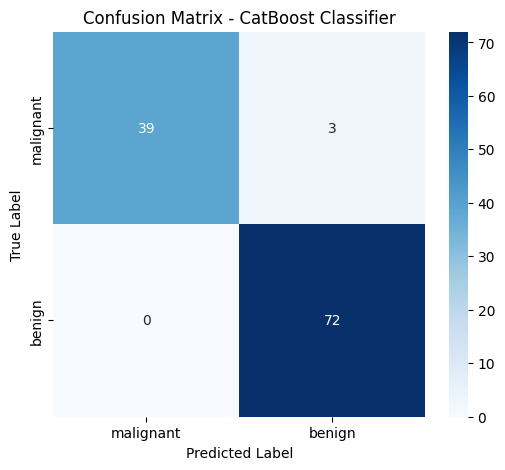

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
!pip install catboost
from catboost import CatBoostClassifier

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_clf = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_state=42
)

cat_clf.fit(X_train, y_train)

y_pred = cat_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"CatBoost Accuracy on Breast Cancer dataset: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CatBoost Classifier")
plt.show()


10.You're working for a FinTech company trying to predict loan default using
customer demographics and transaction behavior.
The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.
Describe your step-by-step data science pipeline using boosting techniques:
- Data preprocessing & handling missing/categorical values
- Choice between AdaBoost, XGBoost, or CatBoost
- Hyperparameter tuning strategy
- Evaluation metrics you'd choose and why
- How the business would benefit from your model

  - 1.Data Preprocessing
    - Handle missing values
      - Numeric features : Impute with median or use iterative imputation.
      - Categorical features : Impute with mode or introduce a "missing" category.

  - Feature Scalling
    - Boosting trees do not require scaling, but scaling helps if you later compare with linear models.

  - Categorical Encoding
    - If using XGBoost : apply one-hot or target encoding.
    - If using CatBoost : Categorical features can be passed directly.

  - Imbalanced Data
    - Apply SMOTE/ADASYN for oversampling or use class weights in boosting algorithms.
    - Stratified test split to preserve class distribution.


 - 2.Choice of Boosting Algorithm
   - AdaBoost : Simple, interpretable, but sensitive to noise and missing values.
  
   - XGBoost : Highly optimized, supports regularization, handles missing values internally, widely used in finace.

   - CatBoost : Best for mixed datasets with categorical features, avoids target leakage with ordered Target Encoding.


  - 3.Hyperparameter Tuning Strategy
    - Use GridSearchCV or RandomizedSearchCV with cross-validation.
    - Key parameters to tune
      - learning_rate : controls step size.
      - n_estimators : number of boosting rounds.
      - max_depth : tree depth, controls complexity.
      - subsample : Prevent overfitting by sampling.
      - reg_alpha : regularization terms.

  - 4.Evaluation Metrics
    - ROC-AUC : measures ability to distinguish defaulters vs non-defaulters.
    - Precision,Recall,F1 : critical because false negative are costly.
    - PR Curve : more informative than ROC when defaults are rare.
    - Confusion Matrix : To visualize false positive vs false negatives

  - 5.Business Benefits
    - Risk Reduction : More accurate identification of potential defaulters reduces financial losses.
    - Fair lending decision : Transparent feature importance builds trust with regulators and customers.
    - Fair lending decisions : Transparent feature importance builds trust with regulators and customers.
    - Customer Retention : By correctly identifing safe borrowers, the company avoids rejecting good customers.
    - Operational Efficiency : Automates risk scoring, enabling faster loan approvals.
    - Regulatory compliance : Interpretable boosting models support explainability requirements in finace.

